In [11]:
import pandas as pd
import numpy as np
import networkx as nx
import json
import os
from datetime import datetime
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

import pickle


In [2]:
# Percorsi dei file (usando il timestamp dai tuoi file esistenti)
out_dir = "./outputs_graph"
timestamp = "20250831_103443"  # o usa il timestamp dei tuoi file

edgelist_path = os.path.join(out_dir, f"citation_graph_edges_{timestamp}.edgelist")
nodes_jsonl_path = os.path.join(out_dir, f"citation_graph_nodes_{timestamp}.jsonl")
gpickle_path = os.path.join(out_dir, f"citation_graph_{timestamp}.gpickle")

In [3]:
def load_citation_graph(edgelist_path, nodes_jsonl_path, use_gpickle=True, gpickle_path=None):
    """
    Carica il grafo da edgelist e nodes JSONL, con opzione per gpickle
    """
    
    # Opzione 1: Carica direttamente da gpickle se disponibile
    if use_gpickle and gpickle_path and os.path.exists(gpickle_path):
        try:
            import pickle
            # Prova prima NetworkX
            try:
                G = nx.read_gpickle(gpickle_path)
                print(f"Caricato grafo da gpickle (NetworkX): {gpickle_path}")
                return G
            except:
                # Fallback con pickle puro
                with open(gpickle_path, 'rb') as f:
                    G = pickle.load(f)
                print(f"Caricato grafo da gpickle (pickle): {gpickle_path}")
                return G
        except Exception as e:
            print(f"Errore nel caricamento gpickle: {e}")
            print("Procedo con edgelist + JSONL...")
    
    # Opzione 2: Ricostruisci da edgelist + JSONL
    print("Caricamento da edgelist e JSONL...")
    
    # Carica edges
    print(f"Caricando edges da: {edgelist_path}")
    if edgelist_path.endswith('.zip'):
        edges_df = pd.read_csv(edgelist_path, sep=' ', names=['source', 'target', 'type'], dtype=str)
    else:
        edges_df = pd.read_csv(edgelist_path, sep=' ', names=['source', 'target', 'type'], dtype=str)
    
    print(f"Caricate {len(edges_df)} edges")
    
    # Carica nodi
    print(f"Caricando nodi da: {nodes_jsonl_path}")
    nodes = []
    
    if nodes_jsonl_path.endswith('.zip'):
        import zipfile
        with zipfile.ZipFile(nodes_jsonl_path, 'r') as zip_file:
            # Assume che ci sia un solo file nel zip
            jsonl_filename = zip_file.namelist()[0]
            with zip_file.open(jsonl_filename, 'r') as f:
                for line in f:
                    line = line.decode('utf-8').strip()
                    if line:
                        nodes.append(json.loads(line))
    else:
        with open(nodes_jsonl_path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if line:
                    nodes.append(json.loads(line))
    
    print(f"Caricati {len(nodes)} nodi")
    
    # Costruisci il grafo
    print("Costruendo il grafo NetworkX...")
    G = nx.from_pandas_edgelist(edges_df, 
                               source='source', 
                               target='target',
                               edge_attr=['type'],
                               create_using=nx.DiGraph())
    
    # Aggiungi attributi ai nodi
    node_attributes = {}
    for node_data in nodes:
        node_id = node_data.pop('id')  # Rimuovi 'id' dagli attributi
        node_attributes[node_id] = node_data
    
    nx.set_node_attributes(G, node_attributes)
    
    print(f"Grafo costruito: {G.number_of_nodes()} nodi, {G.number_of_edges()} archi")
    return G

In [4]:
G = load_citation_graph(edgelist_path, nodes_jsonl_path, use_gpickle=True, gpickle_path=gpickle_path)

Caricato grafo da gpickle (pickle): ./outputs_graph/citation_graph_20250831_103443.gpickle


In [5]:
# ...existing code...
def plot_connected_elements_by_year(G, start_year=2000, end_year=2025, highlight_year=2015):
    """
    Single figure with two vertically stacked plots (shared x-axis).
    The x-axis labels are shown only once (bottom). The annotated intersection
    (percent + count) is placed top-right of the intersection point.
    """
    # classify nodes
    internal_nodes_by_year = {}
    external_nodes = set()
    for node, attrs in G.nodes(data=True):
        if attrs.get('external', False):
            external_nodes.add(node)
        else:
            pub = attrs.get('publicationDate', '')
            year = None
            if isinstance(pub, str) and pub.strip():
                try:
                    year = int(pub.split('-', 1)[0])
                except Exception:
                    year = None
            elif isinstance(pub, (int, float)):
                year = int(pub)
            if year is not None:
                internal_nodes_by_year[node] = year

    total_internal = len(internal_nodes_by_year)
    total_external = len(external_nodes)
    total_global = G.number_of_nodes()
    print(f"Totals (original graph): internal={total_internal}, external={total_external}, global={total_global}")

    years = list(range(start_year, end_year + 1))
    internal_counts = []
    internal_pct = []
    external_connected_counts = []
    external_connected_pct = []

    # helper for neighbors (undirected reach from a node via in/out)
    def neighbors_of(n):
        return set(G.predecessors(n)) | set(G.successors(n))

    for y in years:
        valid_internal = {n for n, yr in internal_nodes_by_year.items() if yr >= y}
        icount = len(valid_internal)
        internal_counts.append(icount)
        pct_i = (icount / total_internal * 100) if total_internal > 0 else 0.0
        internal_pct.append(pct_i)

        # externals connected to any remaining internal
        ext_conn = set()
        for n in valid_internal:
            ext_conn.update(neighbors_of(n) & external_nodes)
        ecount = len(ext_conn)
        external_connected_counts.append(ecount)
        pct_e = (ecount / total_external * 100) if total_external > 0 else 0.0
        external_connected_pct.append(pct_e)

    # choose xticks (max ~10)
    def xticks_for(lst, max_ticks=10):
        if len(lst) <= max_ticks:
            return lst
        step = max(1, len(lst) // max_ticks)
        ticks = lst[::step]
        if lst[-1] not in ticks:
            ticks.append(lst[-1])
        return ticks
    xticks = xticks_for(years)

    # ensure highlight_year is present in xticks for coloring the tick
    if highlight_year not in xticks:
        xticks = sorted(set(xticks) | {highlight_year})

    # clamp highlight_year into range of years and get index
    if highlight_year not in years:
        highlight_year = max(min(highlight_year, years[-1]), years[0])
    idx = years.index(highlight_year)
    pct_i_at = internal_pct[idx]
    cnt_i_at = internal_counts[idx]
    pct_e_at = external_connected_pct[idx]
    cnt_e_at = external_connected_counts[idx]

    # ---------- Single figure with two stacked axes (shared x) ----------
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 7), gridspec_kw={'height_ratios': [1, 1]})

    # Plot 1: internals
    ax1.plot(years, internal_pct, marker='o', markersize=4, linewidth=1.6, color='tab:blue', label='Internals [%]')
    # ax1.set_title('Internals remaining (%) and Externals connected (%)', fontsize=12)
    ax1.set_ylabel('Internals remaining [%]')
    ax1.set_ylim(0, 100)
    ax1.yaxis.set_major_locator(MultipleLocator(10))
    ax1.grid(True, alpha=0.25)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    # vertical dashed line at highlight year
    ax1.axvline(highlight_year, color='red', linestyle='--', linewidth=1.2, alpha=0.9)

    # annotate internals intersection top-right of the point
    ax1.annotate(f"{pct_i_at:.1f}%\n({int(cnt_i_at)})",
                 (highlight_year, pct_i_at),
                 textcoords="offset points", xytext=(8, 8),
                 ha='left', va='bottom', fontsize=9,
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.9))

    # Plot 2: externals
    ax2.plot(years, external_connected_pct, marker='o', markersize=4, linewidth=1.6, color='tab:green', label='Externals connected [%]')
    ax2.set_xlabel('Threshold year (≥)')
    ax2.set_ylabel('Externals connected [%]')
    ax2.set_ylim(0, 100)
    ax2.yaxis.set_major_locator(MultipleLocator(10))
    ax2.grid(True, alpha=0.25)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    # vertical dashed line at highlight year (also on bottom)
    ax2.axvline(highlight_year, color='red', linestyle='--', linewidth=1.2, alpha=0.9)

    # annotate externals intersection top-right of the point
    ax2.annotate(f"{pct_e_at:.1f}%\n({int(cnt_e_at)})",
                 (highlight_year, pct_e_at),
                 textcoords="offset points", xytext=(8, 8),
                 ha='left', va='bottom', fontsize=9,
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.9))

    # set shared x ticks and color the highlight tick red (only bottom axis shows labels)
    xt_labels = [str(x) for x in xticks]
    ax2.set_xticks(xticks)
    ax2.set_xticklabels(xt_labels)
    plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')
    dx = (years[-1] - years[0])
    for lbl in ax2.get_xticklabels():
        x, y = lbl.get_position()
        lbl.set_x(x + dx)
    try:
        tick_i = xt_labels.index(str(highlight_year))
        ax2.get_xticklabels()[tick_i].set_color('red')
        ax2.get_xticklabels()[tick_i].set_fontweight('bold')
    except ValueError:
        pass

    # reduce clutter: hide x tick labels on top axis
    ax1.tick_params(labelbottom=False)

    # legend (optional)
    ax1.legend(loc='upper left', fontsize=9)
    ax2.legend(loc='upper left', fontsize=9)

    try:
        ax1.set_box_aspect(1)
        ax2.set_box_aspect(1)
    except Exception:
        pass

    plt.tight_layout()
    plt.show()

    # ---------- Pre / Post summary at highlight_year ----------
    pre_nodes = G.number_of_nodes()
    pre_edges = G.number_of_edges()
    pre_internal = total_internal
    pre_external = total_external

    # Build filtered graph at highlight_year: remove internals with year < highlight_year
    G_post = G.copy()
    nodes_to_remove = [n for n, yr in internal_nodes_by_year.items() if yr < highlight_year]
    G_post.remove_nodes_from(nodes_to_remove)
    # remove isolates (externals that lost links)
    isolates = list(nx.isolates(G_post))
    G_post.remove_nodes_from(isolates)

    post_nodes = G_post.number_of_nodes()
    post_edges = G_post.number_of_edges()
    post_internal = sum(0 if G_post.nodes[n].get('external', False) else 1 for n in G_post.nodes())
    post_external = post_nodes - post_internal

    print("\n=== Pre / Post filtering summary at threshold year:", highlight_year, "===")
    print(f"{'Type':<10} {'Pre_nodes':>10} {'Post_nodes':>12} {'Pre_edges':>12} {'Post_edges':>12}")
    print(f"{'Global':<10} {pre_nodes:10d} {post_nodes:12d} {pre_edges:12d} {post_edges:12d}")
    print(f"{'Internal':<10} {pre_internal:10d} {post_internal:12d} {'-':12} {'-':12}")
    print(f"{'External':<10} {pre_external:10d} {post_external:12d} {'-':12} {'-':12}")

    # also print intersection numbers at highlight year (only here)
    print("\nIntersection at highlight year (annotated on plots):")
    print(f"  Internals remaining: {cnt_i_at} ({pct_i_at:.1f}% of original internals)")
    print(f"  Externals connected: {cnt_e_at} ({pct_e_at:.1f}% of original externals)")

    # prepare small internals dataframe (id, year) for return
    internals_df = pd.DataFrame(list(internal_nodes_by_year.items()), columns=['node', 'year'])

    return internals_df, years, internal_pct, internal_counts
# ...existing code...

Totals (original graph): internal=122679, external=2206577, global=2329281


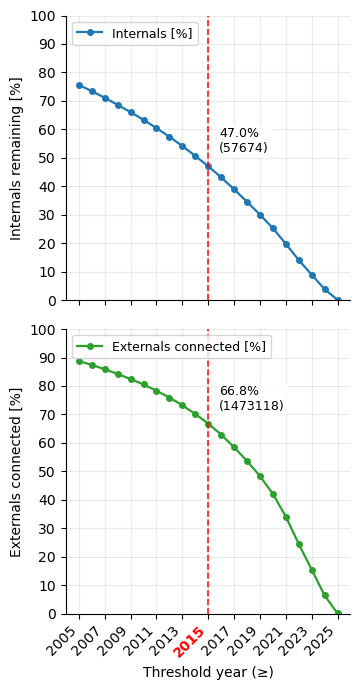


=== Pre / Post filtering summary at threshold year: 2015 ===
Type        Pre_nodes   Post_nodes    Pre_edges   Post_edges
Global        2329281      1531464      4172493      2386937
Internal       122679        57618 -            -           
External      2206577      1473846 -            -           

Intersection at highlight year (annotated on plots):
  Internals remaining: 57674 (47.0% of original internals)
  Externals connected: 1473118 (66.8% of original externals)


In [6]:
df_nodes, years_list, percentages, counts = plot_connected_elements_by_year(G, start_year=2005, end_year=2025, highlight_year=2015)

In [9]:
# ...existing code...
def filter_graph_by_year_and_connectivity(G, year_threshold=2015):
    """
    Filter graph by:
      1) removing internal nodes with publication year < year_threshold
      2) removing any isolated nodes left (internal or external)
    Prints a concise before/after summary and connectivity info.
    Returns the filtered graph.
    """
    def _extract_year(pub):
        if isinstance(pub, str) and pub.strip():
            try:
                return int(pub.split('-', 1)[0])
            except Exception:
                return None
        if isinstance(pub, (int, float)):
            return int(pub)
        return None

    print(f"=== FILTER: KEEP INTERNALS WITH YEAR >= {year_threshold} and DROP ISOLATES ===\n")

    initial_nodes = G.number_of_nodes()
    initial_edges = G.number_of_edges()

    # classify nodes and collect internal years
    nodes_by_year = {}
    initial_internal = 0
    initial_external = 0
    for n, attrs in G.nodes(data=True):
        if attrs.get('external', False):
            initial_external += 1
        else:
            initial_internal += 1
            yr = _extract_year(attrs.get('publicationDate', ''))
            if yr is not None:
                nodes_by_year[n] = yr

    print("1) INITIAL STATE")
    print(f"   Total nodes: {initial_nodes}")
    print(f"   Internal nodes: {initial_internal}")
    print(f"   External nodes: {initial_external}")
    print(f"   Edges: {initial_edges}")
    print(f"   Internals with valid year: {len(nodes_by_year)}\n")

    # remove internals older than threshold
    to_remove_by_year = [n for n, yr in nodes_by_year.items() if yr < year_threshold]
    print("2) YEAR FILTER")
    print(f"   Internals to remove (year < {year_threshold}): {len(to_remove_by_year)}")

    G_filtered = G.copy()
    if to_remove_by_year:
        G_filtered.remove_nodes_from(to_remove_by_year)

    after_year_nodes = G_filtered.number_of_nodes()
    after_year_edges = G_filtered.number_of_edges()
    print(f"   Nodes after year filter: {after_year_nodes}")
    print(f"   Edges after year filter: {after_year_edges}\n")

    # remove isolates
    print("3) REMOVE ISOLATED NODES")
    isolated = list(nx.isolates(G_filtered))
    print(f"   Isolated nodes found: {len(isolated)}")
    isolated_internal = sum(0 if G_filtered.nodes[n].get('external', False) else 1 for n in isolated)
    isolated_external = len(isolated) - isolated_internal
    print(f"     - isolated internals: {isolated_internal}")
    print(f"     - isolated externals: {isolated_external}")

    if isolated:
        G_filtered.remove_nodes_from(isolated)

    # final stats
    final_nodes = G_filtered.number_of_nodes()
    final_edges = G_filtered.number_of_edges()
    final_internal = 0
    final_external = 0
    final_nodes_by_year = {}
    for n, attrs in G_filtered.nodes(data=True):
        if attrs.get('external', False):
            final_external += 1
        else:
            final_internal += 1
            yr = _extract_year(attrs.get('publicationDate', ''))
            if yr is not None:
                final_nodes_by_year[n] = yr

    print("\n4) FINAL STATE")
    print(f"   Total nodes: {final_nodes}")
    print(f"   Internal nodes: {final_internal}")
    print(f"   External nodes: {final_external}")
    print(f"   Edges: {final_edges}")
    if final_nodes_by_year:
        print(f"   Internal year range: {min(final_nodes_by_year.values())} - {max(final_nodes_by_year.values())}")

    # summary of changes
    print("\n5) SUMMARY OF CHANGES")
    print(f"{'Metric':<20} {'Initial':<10} {'Final':<10} {'Delta':<12} {'%':<8}")
    print("-" * 65)
    metrics = [
        ("Total nodes", initial_nodes, final_nodes),
        ("Internal nodes", initial_internal, final_internal),
        ("External nodes", initial_external, final_external),
        ("Edges", initial_edges, final_edges),
    ]
    for name, init, fin in metrics:
        delta = fin - init
        pct = (delta / init * 100) if init > 0 else 0.0
        print(f"{name:<20} {init:<10} {fin:<10} {delta:+<12d} {pct:+.1f}%")

    # connectivity
    print("\n6) CONNECTIVITY")
    if G_filtered.number_of_nodes() == 0:
        print("   Graph is empty after filtering.")
    else:
        G_undir = G_filtered.to_undirected()
        comps = list(nx.connected_components(G_undir))
        print(f"   Connected components: {len(comps)}")
        if len(comps) > 1:
            sizes = sorted((len(c) for c in comps), reverse=True)
            print(f"   Component sizes (desc): {sizes}")
            main = sizes[0]
            print(f"   Largest component: {main} nodes ({main / final_nodes * 100:.1f}%)")

    return G_filtered
# ...existing code...

In [10]:
G_filtered_2015 = filter_graph_by_year_and_connectivity(G, year_threshold=2015)

=== FILTER: KEEP INTERNALS WITH YEAR >= 2015 and DROP ISOLATES ===

1) INITIAL STATE
   Total nodes: 2329281
   Internal nodes: 122704
   External nodes: 2206577
   Edges: 4172493
   Internals with valid year: 122679

2) YEAR FILTER
   Internals to remove (year < 2015): 65005
   Nodes after year filter: 2264276
   Edges after year filter: 2386937

3) REMOVE ISOLATED NODES
   Isolated nodes found: 732812
     - isolated internals: 81
     - isolated externals: 732731

4) FINAL STATE
   Total nodes: 1531464
   Internal nodes: 57618
   External nodes: 1473846
   Edges: 2386937
   Internal year range: 2015 - 2025

5) SUMMARY OF CHANGES
Metric               Initial    Final      Delta        %       
-----------------------------------------------------------------
Total nodes          2329281    1531464    -797817+++++ -34.3%
Internal nodes       122704     57618      -65086++++++ -53.0%
External nodes       2206577    1473846    -732731+++++ -33.2%
Edges                4172493    2386937 

In [12]:
def save_filtered_graph(G, out_dir="./outputs_graph", suffix="post2015"):
    """
    Save filtered graph in multiple formats:
      - edgelist (.edgelist)
      - nodes JSONL (.jsonl)
      - NetworkX gpickle (.gpickle)
      - unified JSON (single file with metadata, nodes, edges)
    Returns a dict with paths and a simple success flag.
    """
    os.makedirs(out_dir, exist_ok=True)
    base = f"citation_graph_{suffix}"
    paths = {
        "edgelist": os.path.join(out_dir, f"{base}.edgelist"),
        "nodes_jsonl": os.path.join(out_dir, f"{base}_nodes.jsonl"),
        "gpickle": os.path.join(out_dir, f"{base}.gpickle"),
        "json_unified": os.path.join(out_dir, f"{base}_unified.json"),
    }

    # 1) edgelist
    try:
        with open(paths["edgelist"], "w", encoding="utf-8") as f:
            for u, v, attrs in G.edges(data=True):
                f.write(f"{u} {v} {attrs.get('type','')}\n")
        print(f"Saved edgelist: {paths['edgelist']}")
    except Exception as e:
        print(f"Failed to save edgelist: {e}")

    # 2) nodes JSONL
    try:
        with open(paths["nodes_jsonl"], "w", encoding="utf-8") as f:
            for node, attrs in G.nodes(data=True):
                rec = {"id": node, **attrs}
                f.write(json.dumps(rec, ensure_ascii=False) + "\n")
        print(f"Saved nodes JSONL: {paths['nodes_jsonl']}")
    except Exception as e:
        print(f"Failed to save nodes JSONL: {e}")

    # 3) gpickle
    try:
        try:
            nx.write_gpickle(G, paths["gpickle"])
        except Exception:
            with open(paths["gpickle"], "wb") as f:
                pickle.dump(G, f, protocol=pickle.HIGHEST_PROTOCOL)
        print(f"Saved gpickle: {paths['gpickle']}")
    except Exception as e:
        print(f"Failed to save gpickle: {e}")

    # 4) unified JSON
    try:
        unified = {
            "metadata": {
                "created": datetime.now().isoformat(),
                "filter_applied": suffix,
                "total_nodes": G.number_of_nodes(),
                "total_edges": G.number_of_edges(),
                "format_version": "1.0",
            },
            "nodes": [{"id": n, **attrs} for n, attrs in G.nodes(data=True)],
            "edges": [{"source": u, "target": v, **attrs} for u, v, attrs in G.edges(data=True)],
        }
        with open(paths["json_unified"], "w", encoding="utf-8") as f:
            json.dump(unified, f, ensure_ascii=False, indent=2)
        print(f"Saved unified JSON: {paths['json_unified']}")
    except Exception as e:
        print(f"Failed to save unified JSON: {e}")

    # summary
    saved = {}
    for key, p in paths.items():
        ok = os.path.exists(p)
        size_mb = os.path.getsize(p) / (1024 * 1024) if ok else None
        saved[key] = {"path": p, "exists": ok, "size_mb": size_mb}
        status = "✓" if ok else "✗"
        size_str = f" ({size_mb:.2f} MB)" if size_mb is not None else ""
        print(f" {status} {key}: {os.path.basename(p)}{size_str}")

    return {
        "edgelist_path": paths["edgelist"],
        "nodes_jsonl_path": paths["nodes_jsonl"],
        "gpickle_path": paths["gpickle"],
        "json_unified_path": paths["json_unified"],
        "saved_successfully": saved["edgelist"]["exists"] and saved["nodes_jsonl"]["exists"],
        "details": saved
    }


In [13]:
save_info = save_filtered_graph(G_filtered_2015, suffix="post2015")

Saved edgelist: ./outputs_graph/citation_graph_post2015.edgelist
Saved nodes JSONL: ./outputs_graph/citation_graph_post2015_nodes.jsonl
Saved gpickle: ./outputs_graph/citation_graph_post2015.gpickle
Saved unified JSON: ./outputs_graph/citation_graph_post2015_unified.json
 ✓ edgelist: citation_graph_post2015.edgelist (225.36 MB)
 ✓ nodes_jsonl: citation_graph_post2015_nodes.jsonl (233.07 MB)
 ✓ gpickle: citation_graph_post2015.gpickle (298.35 MB)
 ✓ json_unified: citation_graph_post2015_unified.json (725.07 MB)


In [ ]:
def count_edges_in_cycles(G):
    """
    Count directed edges that participate in cycles.

    Method: compute strongly connected components (SCC). An edge (u, v)
    is in a cycle iff u and v belong to the same SCC that is either
    size > 1 or a singleton with a self-loop.

    Returns: (count, example_edges, stats)
    """
    sccs = list(nx.strongly_connected_components(G))
    node_to_comp = {}
    comp_size = {}
    for i, comp in enumerate(sccs):
        comp_size[i] = len(comp)
        for n in comp:
            node_to_comp[n] = i

    cyclic_comps = {i for i, sz in comp_size.items() if sz > 1}
    for i, comp in enumerate(sccs):
        if comp_size[i] == 1:
            node = next(iter(comp))
            if G.has_edge(node, node):
                cyclic_comps.add(i)

    examples = []
    count = 0
    for u, v in G.edges():
        cu = node_to_comp.get(u)
        if cu is not None and cu == node_to_comp.get(v) and cu in cyclic_comps:
            count += 1
            if len(examples) < 20:
                examples.append((u, v))

    total_edges = G.number_of_edges()
    percent = (count / total_edges * 100) if total_edges > 0 else 0.0

    stats = {
        "edges_in_cycles": count,
        "total_edges": total_edges,
        "percent": percent,
        "cyclic_scc_count": len(cyclic_comps),
    }

    print(f"Edges in cycles: {count} / {total_edges} ({percent:.3f}%)")
    sample_sizes = sorted([comp_size[i] for i in list(cyclic_comps)], reverse=True)[:10]
    print(f"Cyclic SCC count: {len(cyclic_comps)} (example sizes: {sample_sizes})")

    return count, examples, stats

In [ ]:
count_filt, examples_filt, stats_filt = count_edges_in_cycles(G_filtered_2015)


Edges in cycles: 1794 / 2386937 (0.075%)
Cyclic SCC count: 455 (example sizes: [33, 16, 13, 12, 9, 7, 7, 7, 6, 6])


In [20]:
# ...existing code...
def _choose_edge_by_degree_diff(sub, candidate_edges):
    """Choose an edge by highest source out-degree (fast heuristic)."""
    best = None
    best_score = -float('inf')
    for u, v in candidate_edges:
        score = sub.out_degree(u)
        if score > best_score:
            best_score = score
            best = (u, v)
    return best

def _choose_edge_by_impact(sub, candidate_edges, eval_fn=None, eval_limit_candidates=10_000_000):
    """
    Simulate removal for each candidate and measure reduction in edges-in-cycles.
    Returns (best_edge, delta, baseline). Limits candidates by source out-degree if too many.
    """
    if eval_fn is None:
        eval_fn = lambda H: count_edges_in_cycles(H)[0]

    baseline = eval_fn(sub)
    if baseline == 0:
        return None, 0, baseline

    if len(candidate_edges) > eval_limit_candidates:
        candidate_edges = sorted(candidate_edges, key=lambda e: sub.out_degree(e[0]), reverse=True)[:eval_limit_candidates]

    best = None
    best_delta = 0
    for u, v in candidate_edges:
        if not sub.has_edge(u, v):
            continue
        H = sub.copy()
        H.remove_edge(u, v)
        new_count = eval_fn(H)
        delta = baseline - new_count
        if delta > best_delta:
            best_delta = delta
            best = (u, v)
        if new_count == 0:
            return best or (u, v), best_delta, baseline
    return best, best_delta, baseline

def _extract_year_from_attrs(attrs):
    """Extract year from attrs['publicationDate'] if possible, otherwise return None."""
    if not isinstance(attrs, dict):
        return None
    pub = attrs.get('publicationDate')
    if pub is None:
        return None
    if isinstance(pub, (int, float)):
        try:
            return int(pub)
        except Exception:
            return None
    if isinstance(pub, str):
        s = pub.strip()
        if not s:
            return None
        try:
            return int(s.split('-', 1)[0])
        except Exception:
            try:
                return int(s)
            except Exception:
                return None
    return None

def break_cycles_impact_then_degree(G,
                                    max_scc_impact_nodes=200,
                                    max_removals_per_scc=100,
                                    eval_limit_candidates=200):
    """
    Break directed cycles in G.

    For each cyclic SCC:
      - if SCC is small (<= max_scc_impact_nodes), try iterative 'impact' removals:
          simulate removals and pick the edge whose removal reduces the most edges-in-cycles
      - otherwise (or if impact fails), remove an edge chosen by degree-difference heuristic

    Returns (G_out, removed_list, stats).
    removed_list entries: (u, v, method, info...)
    """
    G_out = G.copy()
    removed = []

    # Step 0: remove temporally inverted edges (source_year < target_year)
    temporal_removed = []
    for u, v in list(G_out.edges()):
        ys = _extract_year_from_attrs(G_out.nodes.get(u, {}))
        yt = _extract_year_from_attrs(G_out.nodes.get(v, {}))
        if ys is not None and yt is not None and ys < yt and G_out.has_edge(u, v):
            G_out.remove_edge(u, v)
            info = {'source_year': ys, 'target_year': yt}
            removed.append((u, v, 'temporal_inversion', info))
            temporal_removed.append((u, v, ys, yt))
    if temporal_removed:
        print(f"Removed {len(temporal_removed)} temporally inverted edges (source.year < target.year).")
    else:
        print("No temporally inverted edges removed.")

    # Continue with cycle-breaking
    sccs = list(nx.strongly_connected_components(G_out))
    for comp in sccs:
        # skip non-cyclic singletons without self-loop
        if len(comp) == 1:
            node = next(iter(comp))
            if not G_out.has_edge(node, node):
                continue

        removals = 0
        while removals < max_removals_per_scc:
            H_nodes = set(comp)
            H = G_out.subgraph(H_nodes).copy()

            # find inner SCCs that are cyclic (size>1 or self-loop)
            inner_sccs = [c for c in nx.strongly_connected_components(H)
                          if len(c) > 1 or (len(c) == 1 and H.has_edge(next(iter(c)), next(iter(c))))]
            if not inner_sccs:
                break

            # pick the largest sub-SCC
            target = max(inner_sccs, key=len)
            sub = H.subgraph(target).copy()

            # candidate edges: "backward" edges in greedy order (outdeg - indeg)
            scores = {n: sub.out_degree(n) - sub.in_degree(n) for n in sub.nodes()}
            order = sorted(sub.nodes(), key=lambda n: scores[n], reverse=True)
            pos = {n: i for i, n in enumerate(order)}
            candidate_edges = [(u, v) for u, v in sub.edges() if pos.get(u, 0) > pos.get(v, 0)]
            if not candidate_edges:
                candidate_edges = list(sub.edges())

            # policy: try impact if small, otherwise fallback to degree heuristic
            if len(sub) <= max_scc_impact_nodes:
                best, delta, baseline = _choose_edge_by_impact(sub, candidate_edges,
                                                               eval_fn=lambda H: count_edges_in_cycles(H)[0],
                                                               eval_limit_candidates=eval_limit_candidates)
                if best and G_out.has_edge(*best):
                    G_out.remove_edge(*best)
                    removed.append((best[0], best[1], 'impact', {'delta': delta, 'baseline': baseline}))
                    removals += 1
                    continue  # re-evaluate this component

            # fallback: degree-diff
            best_deg = _choose_edge_by_degree_diff(sub, candidate_edges)
            if best_deg and G_out.has_edge(*best_deg):
                G_out.remove_edge(*best_deg)
                removed.append((best_deg[0], best_deg[1], 'degree_diff', {'source_outdeg': G.out_degree(best_deg[0])}))
                removals += 1
                continue

            # nothing removed => exit loop
            break

    try:
        is_dag = nx.is_directed_acyclic_graph(G_out)
    except Exception:
        is_dag = False

    stats = {
        'removed_count': len(removed),
        'is_dag': is_dag
    }
    print(f"Removed edges total: {len(removed)}; Graph is DAG: {is_dag}")
    return G_out, removed, stats


In [22]:
G2, removed_list, stats = break_cycles_impact_then_degree(G_filtered_2015)
print("------------------------------")
count_after, _, _ = count_edges_in_cycles(G2)
print('Edges in cycles after:', count_after)


Removed 867 temporally inverted edges (source.year < target.year).
Cyclic SCC count: 1 (example sizes: [2])
Cyclic SCC count: 0 (example sizes: [])
Cyclic SCC count: 1 (example sizes: [2])
Cyclic SCC count: 0 (example sizes: [])
Cyclic SCC count: 1 (example sizes: [6])
Cyclic SCC count: 1 (example sizes: [6])
Cyclic SCC count: 1 (example sizes: [6])
Cyclic SCC count: 1 (example sizes: [6])
Cyclic SCC count: 1 (example sizes: [5])
Cyclic SCC count: 1 (example sizes: [5])
Cyclic SCC count: 1 (example sizes: [6])
Cyclic SCC count: 1 (example sizes: [6])
Cyclic SCC count: 1 (example sizes: [5])
Cyclic SCC count: 1 (example sizes: [5])
Cyclic SCC count: 1 (example sizes: [5])
Cyclic SCC count: 1 (example sizes: [5])
Cyclic SCC count: 1 (example sizes: [5])
Cyclic SCC count: 1 (example sizes: [5])
Cyclic SCC count: 1 (example sizes: [5])
Cyclic SCC count: 1 (example sizes: [5])
Cyclic SCC count: 1 (example sizes: [5])
Cyclic SCC count: 1 (example sizes: [5])
Cyclic SCC count: 1 (example size

In [23]:
save_info = save_filtered_graph(G2, suffix="acyclic_post2015")

Saved edgelist: ./outputs_graph/citation_graph_acyclic_post2015.edgelist
Saved nodes JSONL: ./outputs_graph/citation_graph_acyclic_post2015_nodes.jsonl
Saved gpickle: ./outputs_graph/citation_graph_acyclic_post2015.gpickle
Saved unified JSON: ./outputs_graph/citation_graph_acyclic_post2015_unified.json
 ✓ edgelist: citation_graph_acyclic_post2015.edgelist (225.24 MB)
 ✓ nodes_jsonl: citation_graph_acyclic_post2015_nodes.jsonl (233.07 MB)
 ✓ gpickle: citation_graph_acyclic_post2015.gpickle (298.26 MB)
 ✓ json_unified: citation_graph_acyclic_post2015_unified.json (724.87 MB)
